<a href="https://colab.research.google.com/github/sandip-1996/PRML_exercise_code_example/blob/Probability-distribution-ch.-2/sequantial_bayesian_update_unknown_mean_unknown_precision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


KEY PRML FORMULAS IMPLEMENTED
1. LIKELIHOOD (Eq 2.145):
   p(X|μ,λ) ∝ λ^(N/2) * exp(-λ/2 * Σ(x_n-μ)²)

2. PRIOR (Eq 2.154):
   p(μ,λ) = N(μ|μ_0, (βλ)⁻¹) * Gam(λ|a,b)

3. POSTERIOR PARAMETERS:
   μ_N = (β*μ_0 + N*x̄) / (β + N)
   β_N = β + N
   a_N = a + N/2
   b_N = b + ½*Σ(x_n-x̄)² + ½*(β*N*(x̄-μ_0)²)/(β+N)

4. MARGINAL DISTRIBUTIONS:
   p(λ|X) = Gam(λ|a_N, b_N)
   p(μ|X) = Student-t distribution
=== Bayesian Gaussian with Unknown μ and λ ===

True parameters: μ = 2.0, σ² = 0.5, λ = 2.000
Prior parameters:
  μ_0 = 0.0, β = 1.0
  a = 2.0, b = 1.0

Sequential Bayesian updates:
----------------------------------------
After 1 data points:
  μ_N = 1.176, β_N = 2.000
  a_N = 2.500, b_N = 2.382
Posterior marginals after 1 points:
  E[μ] = 1.176 (true: 2.0)
  E[λ] = 1.050 (true: 2.000)
  E[σ²] = 0.953 (true: 0.5)

After 2 data points:
  μ_N = 1.418, β_N = 3.000
  a_N = 3.000, b_N = 2.558
After 3 data points:
  μ_N = 1.678, β_N = 4.000
  a_N = 3.500, b_N = 2.964
After 4 data points:
  μ_N = 

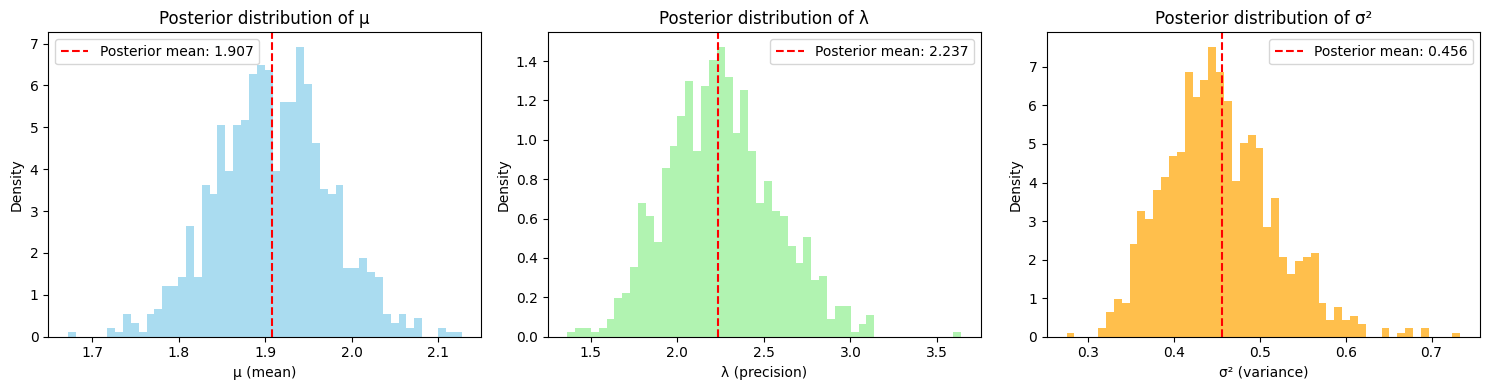


=== Final Results ===
True μ: 2.0, Posterior E[μ]: 1.907
True σ²: 0.5, Posterior E[σ²]: 0.447
True λ: 2.000, Posterior E[λ]: 2.237


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, gamma
import seaborn as sns

class BayesianGaussianUnknownMuLambda:
    """
    Bayesian inference for Gaussian with unknown mean (μ) and unknown precision (λ)
    Following PRML Section 2.3.6
    """

    def __init__(self, mu_0, beta, a, b):
        """
        Initialize with Normal-Gamma prior parameters

        Parameters match PRML equation 2.154:
        p(μ,λ) = N(μ|μ_0, (βλ)^{-1}) * Gam(λ|a,b)
        """
        self.mu_0 = mu_0      # Prior mean for μ
        self.beta = beta      # Scales precision of μ
        self.a = a            # Shape parameter for gamma prior on λ
        self.b = b            # Rate parameter for gamma prior on λ

        # Track posterior parameters as we observe data
        self.mu_N = mu_0
        self.beta_N = beta
        self.a_N = a
        self.b_N = b

        self.data = []

    def likelihood(self, X, mu, lam):
        """
        Likelihood function - PRML Equation 2.145 (generalized for multiple points)
        p(X|μ,λ) = ∏[n=1 to N] N(x_n|μ, λ^{-1})
        """
        # For numerical stability, work with log-likelihood
        N = len(X)
        log_likelihood = (N/2) * np.log(lam) - (lam/2) * np.sum((X - mu)**2)
        return np.exp(log_likelihood)

    def update_posterior(self, x_new):
        """
        Sequential Bayesian update - PRML Equations 2.150-2.151 (extended for μ)
        """
        self.data.append(x_new)
        N = len(self.data)
        X = np.array(self.data)

        # PRML-style parameter updates
        # For μ (similar to equations 2.141-2.142 but for unknown λ)
        x_bar = np.mean(X)  # μ_ML
        S = np.sum((X - x_bar)**2)  # Sum of squares

        # Posterior parameters (derived from conjugate prior analysis)
        self.beta_N = self.beta + N
        self.mu_N = (self.beta * self.mu_0 + N * x_bar) / self.beta_N
        self.a_N = self.a + N/2
        self.b_N = self.b + 0.5 * S + 0.5 * (self.beta * N * (x_bar - self.mu_0)**2) / self.beta_N

        print(f"After {N} data points:")
        print(f"  μ_N = {self.mu_N:.3f}, β_N = {self.beta_N:.3f}")
        print(f"  a_N = {self.a_N:.3f}, b_N = {self.b_N:.3f}")

    def get_posterior_marginals(self):
        """
        Get marginal posterior distributions
        """
        # Marginal for λ: Gamma distribution - PRML Equation 2.149-2.151
        lambda_mean = self.a_N / self.b_N  # E[λ] = a/b
        lambda_var = self.a_N / (self.b_N**2)  # Var[λ] = a/b²

        # Marginal for μ: Student's t-distribution (approximate for visualization)
        # For large samples, approximately N(μ_N, (β_N * (a_N/b_N))^{-1})
        mu_std = 1.0 / np.sqrt(self.beta_N * (self.a_N / self.b_N))

        return {
            'mu_mean': self.mu_N,
            'mu_std': mu_std,
            'lambda_mean': lambda_mean,
            'lambda_var': lambda_var,
            'precision_mean': lambda_mean,  # λ is precision
            'variance_mean': 1.0 / lambda_mean  # σ² = 1/λ
        }

    def sample_posterior(self, n_samples=1000):
        """
        Sample from the joint posterior p(μ,λ|X)
        """
        # Sample λ from Gamma posterior
        lambda_samples = np.random.gamma(self.a_N, 1/self.b_N, n_samples)

        # Sample μ from conditional Gaussian p(μ|λ,X)
        mu_samples = []
        for lam in lambda_samples:
            # μ|λ,X ~ N(μ_N, (β_N * λ)^{-1})
            mu_std = 1.0 / np.sqrt(self.beta_N * lam)
            mu_sample = np.random.normal(self.mu_N, mu_std)
            mu_samples.append(mu_sample)

        return np.array(mu_samples), np.array(lambda_samples)

    def plot_posterior(self):
        """Plot the posterior distributions"""
        mu_samples, lambda_samples = self.sample_posterior(1000)

        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

        # Plot μ posterior
        ax1.hist(mu_samples, bins=50, density=True, alpha=0.7, color='skyblue')
        ax1.axvline(self.mu_N, color='red', linestyle='--', label=f'Posterior mean: {self.mu_N:.3f}')
        ax1.set_xlabel('μ (mean)')
        ax1.set_ylabel('Density')
        ax1.set_title('Posterior distribution of μ')
        ax1.legend()

        # Plot λ posterior
        ax2.hist(lambda_samples, bins=50, density=True, alpha=0.7, color='lightgreen')
        lambda_mean = self.a_N / self.b_N
        ax2.axvline(lambda_mean, color='red', linestyle='--', label=f'Posterior mean: {lambda_mean:.3f}')
        ax2.set_xlabel('λ (precision)')
        ax2.set_ylabel('Density')
        ax2.set_title('Posterior distribution of λ')
        ax2.legend()

        # Plot σ² posterior (variance = 1/λ)
        variance_samples = 1.0 / lambda_samples
        ax3.hist(variance_samples, bins=50, density=True, alpha=0.7, color='orange')
        variance_mean = self.b_N / (self.a_N - 1)  # Mode of inverse gamma
        ax3.axvline(variance_mean, color='red', linestyle='--', label=f'Posterior mean: {variance_mean:.3f}')
        ax3.set_xlabel('σ² (variance)')
        ax3.set_ylabel('Density')
        ax3.set_title('Posterior distribution of σ²')
        ax3.legend()

        plt.tight_layout()
        plt.show()

# Example usage that matches PRML concepts
def demonstrate_bayesian_learning():
    """
    Demonstrate the complete Bayesian learning process
    """
    print("=== Bayesian Gaussian with Unknown μ and λ ===\n")

    # True parameters (unknown to our model)
    true_mu = 2.0
    true_variance = 0.5
    true_lambda = 1.0 / true_variance  # λ = 1/σ²

    print(f"True parameters: μ = {true_mu}, σ² = {true_variance}, λ = {true_lambda:.3f}")

    # PRML Equation 2.154: Initialize with Normal-Gamma prior
    # p(μ,λ) = N(μ|μ_0, (βλ)^{-1}) * Gam(λ|a,b)
    bayesian_model = BayesianGaussianUnknownMuLambda(
        mu_0=0.0,    # Prior guess for mean
        beta=1.0,    # Prior "pseudo-count" for mean
        a=2.0,       # Shape parameter for gamma prior on λ
        b=1.0        # Rate parameter for gamma prior on λ
    )

    print(f"Prior parameters:")
    print(f"  μ_0 = {bayesian_model.mu_0}, β = {bayesian_model.beta}")
    print(f"  a = {bayesian_model.a}, b = {bayesian_model.b}")
    print()

    # Generate data from true distribution
    np.random.seed(42)
    data = np.random.normal(true_mu, np.sqrt(true_variance), 100)

    # Sequential Bayesian updates (show evolution)
    print("Sequential Bayesian updates:")
    print("-" * 40)

    # Update with data in batches to see learning
    batch_sizes = [1, 5, 10, 50, 100]
    current_idx = 0

    for batch_size in batch_sizes:
        if batch_size > current_idx:
            new_data = data[current_idx:batch_size]
            for x in new_data:
                bayesian_model.update_posterior(x)
            current_idx = batch_size

            # Show posterior marginals
            marginals = bayesian_model.get_posterior_marginals()
            print(f"Posterior marginals after {batch_size} points:")
            print(f"  E[μ] = {marginals['mu_mean']:.3f} (true: {true_mu})")
            print(f"  E[λ] = {marginals['lambda_mean']:.3f} (true: {true_lambda:.3f})")
            print(f"  E[σ²] = {marginals['variance_mean']:.3f} (true: {true_variance})")
            print()

    # Final visualization
    print("Generating posterior plots...")
    bayesian_model.plot_posterior()

    # Show how close we got to true parameters
    final_marginals = bayesian_model.get_posterior_marginals()
    print("\n=== Final Results ===")
    print(f"True μ: {true_mu}, Posterior E[μ]: {final_marginals['mu_mean']:.3f}")
    print(f"True σ²: {true_variance}, Posterior E[σ²]: {final_marginals['variance_mean']:.3f}")
    print(f"True λ: {true_lambda:.3f}, Posterior E[λ]: {final_marginals['lambda_mean']:.3f}")

# Additional utility to show the mathematical formulas
def show_formulas():
    """Display the key PRML formulas"""
    print("\n" + "="*60)
    print("KEY PRML FORMULAS IMPLEMENTED")
    print("="*60)
    print("1. LIKELIHOOD (Eq 2.145):")
    print("   p(X|μ,λ) ∝ λ^(N/2) * exp(-λ/2 * Σ(x_n-μ)²)")
    print()
    print("2. PRIOR (Eq 2.154):")
    print("   p(μ,λ) = N(μ|μ_0, (βλ)⁻¹) * Gam(λ|a,b)")
    print()
    print("3. POSTERIOR PARAMETERS:")
    print("   μ_N = (β*μ_0 + N*x̄) / (β + N)")
    print("   β_N = β + N")
    print("   a_N = a + N/2")
    print("   b_N = b + ½*Σ(x_n-x̄)² + ½*(β*N*(x̄-μ_0)²)/(β+N)")
    print()
    print("4. MARGINAL DISTRIBUTIONS:")
    print("   p(λ|X) = Gam(λ|a_N, b_N)")
    print("   p(μ|X) = Student-t distribution")
    print("="*60)

if __name__ == "__main__":
    show_formulas()
    demonstrate_bayesian_learning()